In [36]:
# Import data in pd format

import pandas as pd

delta_call = pd.read_csv("delta/delta_call.csv", sep=";", escapechar="\\", engine="python")
delta_call_cev = pd.read_csv("delta/delta_call_cev.csv", sep=";", escapechar="\\", engine="python")
delta_put = pd.read_csv("delta/delta_put.csv", sep=";", escapechar="\\", engine="python")
delta_bin_call = pd.read_csv("delta/delta_bin_call.csv", sep=";", escapechar="\\", engine="python")
delta_call_1e5 = pd.read_csv("delta/delta_call_1e5.csv", sep=";", escapechar="\\", engine="python")
delta_put_cev = pd.read_csv("delta/delta_put_cev.csv", sep=";", escapechar="\\", engine="python")
delta_call_var_con_1e5 = pd.read_csv("delta/delta_call_var_con_1e5.csv", sep=";", escapechar="\\", engine="python")
delta_bin_put = pd.read_csv("delta/delta_bin_put.csv", sep=";", escapechar="\\", engine="python")
delta_bin_put_cev = pd.read_csv("delta/delta_bin_put_cev.csv", sep=";", escapechar="\\", engine="python")
delta_bin_call_cev = pd.read_csv("delta/delta_bin_call_cev.csv", sep=";", escapechar="\\", engine="python")
delta_call_var_con_anti_1e5 = pd.read_csv("delta/delta_call_var_con_anti_1e5.csv", sep=";", escapechar="\\", engine="python")

gamma_put = pd.read_csv("gamma/gamma_put.csv", sep=";", escapechar="\\", engine="python")
gamma_bin_call = pd.read_csv("gamma/gamma_bin_call.csv", sep=";", escapechar="\\", engine="python")
gamma_put_cev = pd.read_csv("gamma/gamma_put_cev.csv", sep=";", escapechar="\\", engine="python")
gamma_bin_put = pd.read_csv("gamma/gamma_bin_put.csv", sep=";", escapechar="\\", engine="python")
gamma_bin_put_cev = pd.read_csv("gamma/gamma_bin_put_cev.csv", sep=";", escapechar="\\", engine="python")
gamma_bin_call_cev = pd.read_csv("gamma/gamma_bin_call_cev.csv", sep=";", escapechar="\\", engine="python")

vega_put = pd.read_csv("vega/vega_put.csv", sep=";", escapechar="\\", engine="python")
vega_bin_call = pd.read_csv("vega/vega_bin_call.csv", sep=";", escapechar="\\", engine="python")
vega_bin_put = pd.read_csv("vega/vega_bin_put.csv", sep=";", escapechar="\\", engine="python")
vega_bin_put_cev = pd.read_csv("vega/vega_bin_put_cev.csv", sep=";", escapechar="\\", engine="python")
vega_put_cev = pd.read_csv("vega/vega_put_cev.csv", sep=";", escapechar="\\", engine="python")


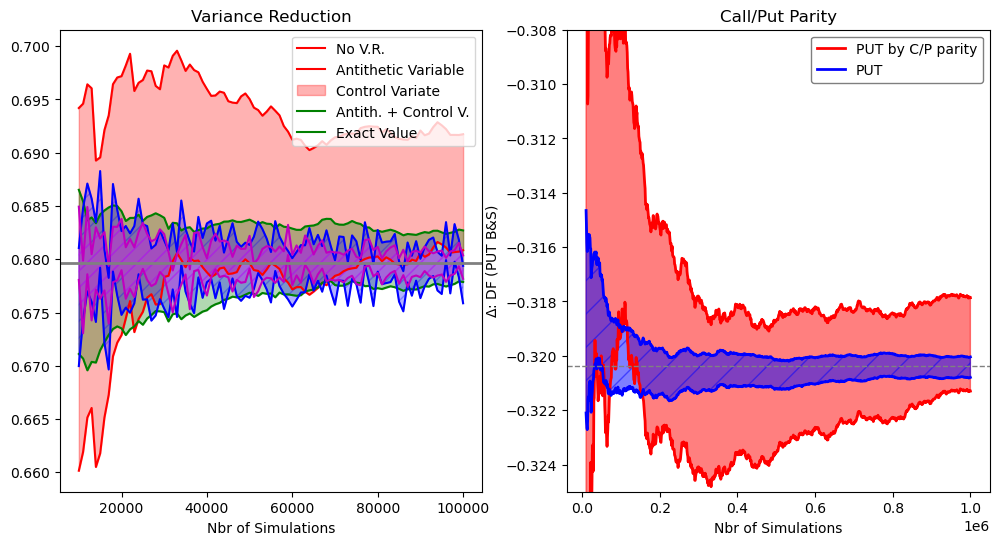

In [53]:
# Plots

import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(12, 6)

# Var reduction
ax1.plot(delta_call["Nb sim"][:91], delta_call["DF"][:91]-delta_call["IC_DF"][:91], 'r-', label=r'$\Delta: DF$ (CALL B&S)')
ax1.plot(delta_call["Nb sim"][:91], delta_call["DF"][:91]+delta_call["IC_DF"][:91], 'r-')
ax1.fill_between(delta_call["Nb sim"][:91], delta_call["DF"][:91]-delta_call["IC_DF"][:91], delta_call["DF"][:91]+delta_call["IC_DF"][:91], color='red', alpha=0.3)
ax1.plot(delta_call["Nb sim"][:91], delta_call["DF_anti"][:91]-delta_call["IC_DF_anti"][:91], 'g-', label='Antithetic Variable')
ax1.plot(delta_call["Nb sim"][:91], delta_call["DF_anti"][:91]+delta_call["IC_DF_anti"][:91], 'g-')
ax1.fill_between(delta_call["Nb sim"][:91], delta_call["DF_anti"][:91]-delta_call["IC_DF_anti"][:91], delta_call["DF_anti"][:91]+delta_call["IC_DF_anti"][:91], color='green', alpha=0.3)
ax1.plot(delta_call_var_con_1e5["Nb sim"], delta_call_var_con_1e5["DF_var_con"]-delta_call_var_con_1e5["IC_DF_var_con"], 'b-', label='Control Variate')
ax1.plot(delta_call_var_con_1e5["Nb sim"], delta_call_var_con_1e5["DF_var_con"]+delta_call_var_con_1e5["IC_DF_var_con"], 'b-')
ax1.fill_between(delta_call_var_con_1e5["Nb sim"], delta_call_var_con_1e5["DF_var_con"]-delta_call_var_con_1e5["IC_DF_var_con"], delta_call_var_con_1e5["DF_var_con"]+delta_call_var_con_1e5["IC_DF_var_con"], color='blue', alpha=0.3, hatch='//')
ax1.plot(delta_call_var_con_anti_1e5["Nb sim"], delta_call_var_con_anti_1e5["DF_var_con"]-delta_call_var_con_anti_1e5["IC_DF_var_con"], 'm-', label='Antith. + Control V.')
ax1.plot(delta_call_var_con_anti_1e5["Nb sim"], delta_call_var_con_anti_1e5["DF_var_con"]+delta_call_var_con_anti_1e5["IC_DF_var_con"], 'm-')
ax1.fill_between(delta_call_var_con_anti_1e5["Nb sim"], delta_call_var_con_anti_1e5["DF_var_con"]-delta_call_var_con_anti_1e5["IC_DF_var_con"], delta_call_var_con_anti_1e5["DF_var_con"]+delta_call_var_con_anti_1e5["IC_DF_var_con"], color='magenta', alpha=0.3, hatch='//')
ax1.axhline(y=0.67963, color='grey', linestyle='-', linewidth=2)
ax1.set_xlabel("Nbr of Simulations")
ax1.legend(["No V.R.", "Antithetic Variable", "Control Variate", "Antith. + Control V.", "Exact Value"], loc='upper right', fontsize=10)
ax1.set_title('Variance Reduction')


# Var reduction
# Plot 1
ax2.plot(delta_call['Nb sim'], delta_call['DF']-1-delta_call['IC_DF'], color='red', linewidth=2, label='PUT by C/P parity')
ax2.plot(delta_call['Nb sim'], delta_call['DF']-1+delta_call['IC_DF'], color='red', linewidth=2)
ax2.fill_between(delta_call['Nb sim'], delta_call['DF']-1-delta_call['IC_DF'], delta_call['DF']-1+delta_call['IC_DF'], color='red', alpha=0.5)
# Plot 2
ax2.plot(delta_put['Nb sim'], delta_put['DF_anti']-delta_put['IC_DF_anti'], color='blue', linewidth=2, label='PUT')
ax2.plot(delta_put['Nb sim'], delta_put['DF_anti']+delta_put['IC_DF_anti'], color='blue', linewidth=2)
ax2.fill_between(delta_put['Nb sim'], delta_put['DF_anti']-delta_put['IC_DF_anti'], delta_put['DF_anti']+delta_put['IC_DF_anti'], color='blue', alpha=0.5, hatch='/')
# Add horizontal line
ax2.axhline(y=0.67963-1, color='gray', linewidth=1, linestyle='--')
# Set axis limits and labels
ax2.set_ylim([-0.325,-0.308])
ax2.set_xlabel('Nbr of Simulations')
ax2.set_ylabel(r'$\Delta$: DF (PUT B&S)')
ax2.set_title('Call/Put Parity')
# Add legend
ax2.legend(loc='upper right', fontsize=10, fancybox=True, framealpha=0.5, edgecolor='black')


plt.show()



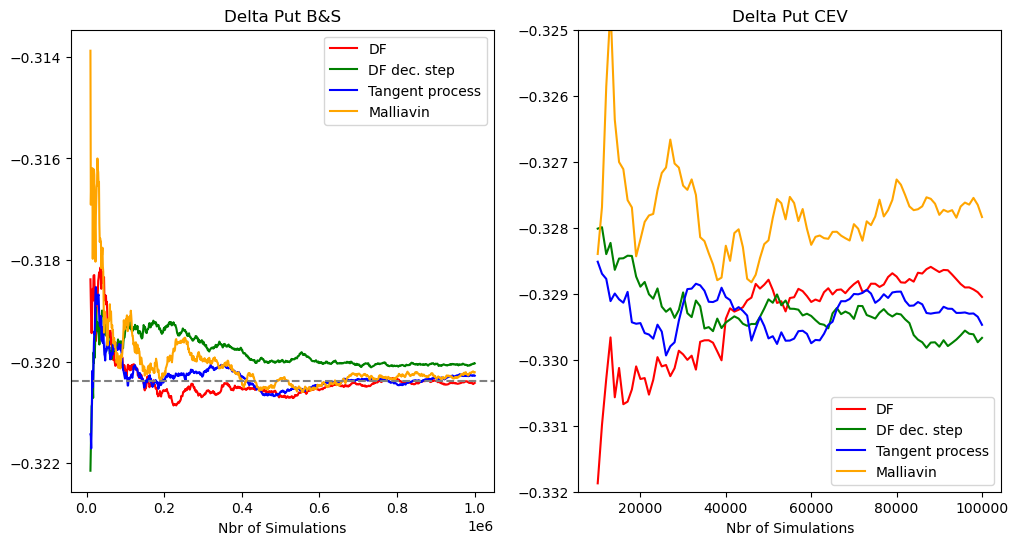

In [68]:
# Delta plots

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(12, 6)

ax1.plot(delta_put["Nb sim"], delta_put["DF_anti"], label="DF", color="red")
ax1.plot(delta_put["Nb sim"], delta_put["DF_d_anti"], label="DF dec. step", color="green")
ax1.plot(delta_put["Nb sim"], delta_put["Tan_anti"], label="Tangent process", color="blue")
ax1.plot(delta_put["Nb sim"], delta_put["Mall_anti"], label="Malliavin", color="orange")
ax1.axhline(y=0.67963-1, color="gray", linestyle="--")

ax1.set_xlabel("Nbr of Simulations")
ax1.set_ylabel("")
ax1.legend(loc="upper right")
ax1.set_title('Delta Put B&S')



ax2.plot(delta_put_cev["Nb sim"], delta_put_cev["DF_anti"], label="DF", color="red")
ax2.plot(delta_put_cev["Nb sim"], delta_put_cev["DF_d_anti"], label="DF dec. step", color="green")
ax2.plot(delta_put_cev["Nb sim"], delta_put_cev["Tan_anti"], label="Tangent process", color="blue")
ax2.plot(delta_put_cev["Nb sim"], delta_put_cev["Mall_anti"], label="Malliavin", color="orange")

ax2.set_ylim(-0.332, -0.325)

ax2.set_xlabel("Nbr of Simulations")
ax2.set_ylabel("")
ax2.legend(loc="lower right")
ax2.set_title('Delta Put CEV')

plt.show()



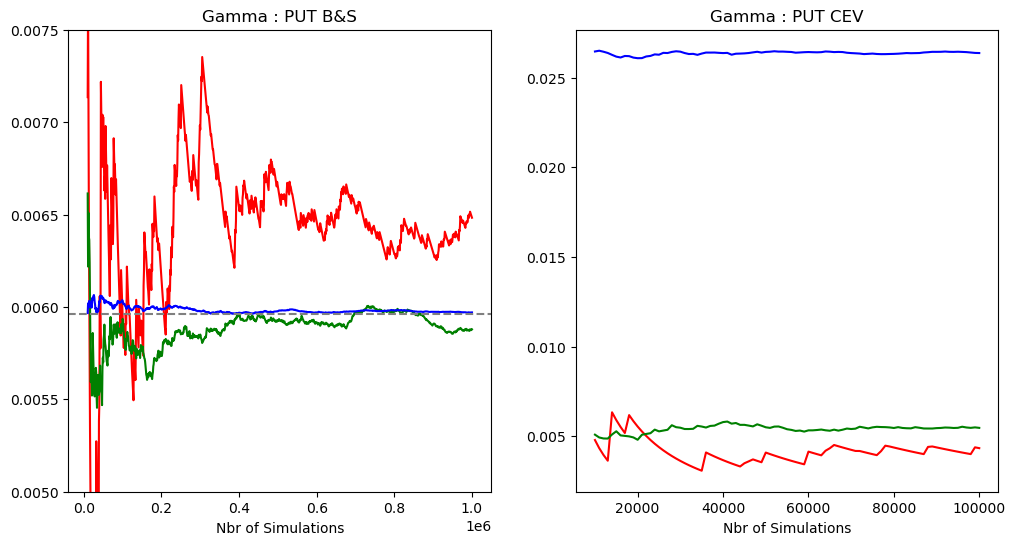

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(12, 6)

# plotting the first line
ax1.plot(gamma_put['Nb sim'], gamma_put['DF_anti'], color='red', label='DF', linestyle='solid')

# plotting the second line
ax1.plot(gamma_put['Nb sim'], gamma_put['DF_d_anti'], color='green', label='DF dec. step', linestyle='solid')

# plotting the third line
ax1.plot(gamma_put['Nb sim'], gamma_put['Mall_anti'], color='blue', label='Malliavin', linestyle='solid')

# plotting the horizontal line
ax1.axhline(y=0.00596, color='grey', linestyle='dashed', label='Exact Value')

# setting y-axis limits
ax1.set_ylim(0.005, 0.0075)

# adding labels to the axes
ax1.set_xlabel('Nbr of Simulations')
ax1.set_ylabel('')
ax1.set_title('Gamma : PUT B&S')

# plotting the first line
ax2.plot(gamma_put_cev['Nb sim'], gamma_put_cev['DF_anti'], color='red', label='DF', linestyle='solid')

# plotting the second line
ax2.plot(gamma_put_cev['Nb sim'], gamma_put_cev['DF_d_anti'], color='green', label='DF dec. step', linestyle='solid')

# plotting the third line
ax2.plot(gamma_put_cev['Nb sim'], gamma_put_cev['Mall_anti'], color='blue', label='Malliavin', linestyle='solid')

# adding labels to the axes
ax2.set_xlabel('Nbr of Simulations')
ax2.set_ylabel('')
ax2.set_title('Gamma : PUT CEV')


plt.show()

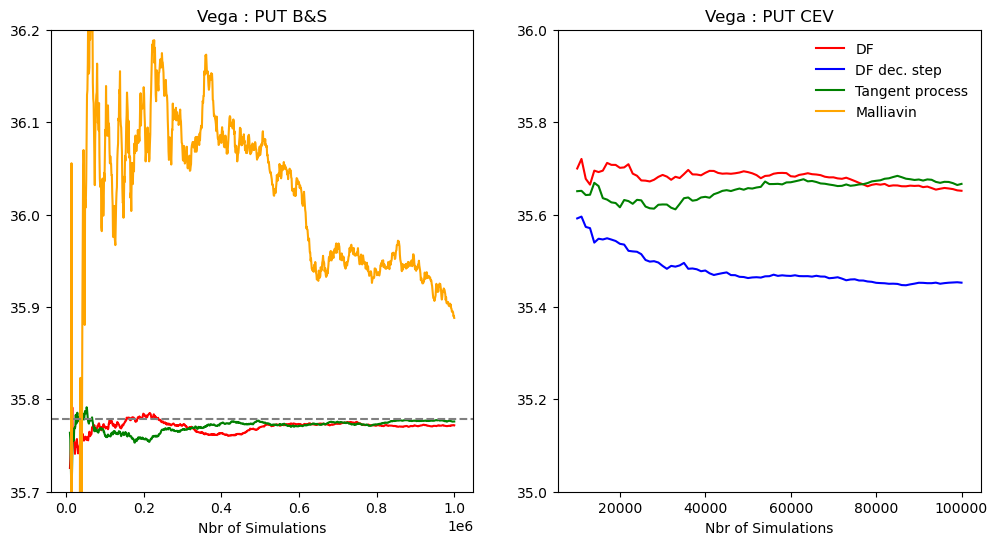

In [74]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(12, 6)

# plot settings
ax1.set_ylim(35.7, 36.2)
ax1.set_xlabel("Nbr of Simulations")
ax1.set_ylabel("")
ax1.set_title("Vega : PUT B&S")

# plot lines
ax1.plot(vega_put['Nb sim'], vega_put['DF_anti'], color='red', label='DF')
ax1.plot(vega_put['Nb sim'], vega_put['DF_d_anti'], color='blue', label='DF dec. step')
ax1.plot(vega_put['Nb sim'], vega_put['Tan_anti'], color='green', label='Tangent process')
ax1.plot(vega_put['Nb sim'], vega_put['Mall_anti'], color='orange', label='Malliavin')
ax1.axhline(y=35.77834, color='gray', linestyle='--')

ax2.set_ylim(35, 36)
ax2.set_xlabel("Nbr of Simulations")
ax2.set_ylabel("")
ax2.set_title("Vega : PUT CEV")

# plot lines
ax2.plot(vega_put_cev['Nb sim'], vega_put_cev['DF_anti'], color='red', label='DF')
ax2.plot(vega_put_cev['Nb sim'], vega_put_cev['DF_d_anti'], color='blue', label='DF dec. step')
ax2.plot(vega_put_cev['Nb sim'], vega_put_cev['Tan_anti'], color='green', label='Tangent process')
ax2.plot(vega_put_cev['Nb sim'], vega_put_cev['Mall_anti'], color='orange', label='Malliavin')

# add legend
plt.legend(loc='upper right', frameon=False)
plt.show()





In [75]:
# Binary Options


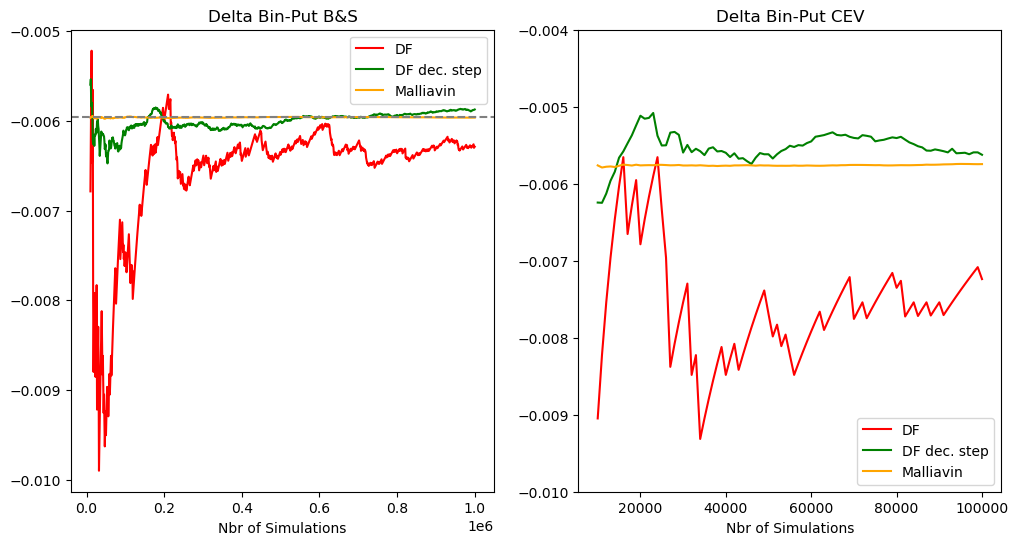

In [79]:
# Delta plots

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(12, 6)

ax1.plot(delta_bin_put["Nb sim"], delta_bin_put["DF_anti"], label="DF", color="red")
ax1.plot(delta_bin_put["Nb sim"], delta_bin_put["DF_d_anti"], label="DF dec. step", color="green")
ax1.plot(delta_bin_put["Nb sim"], delta_bin_put["Mall_anti"], label="Malliavin", color="orange")
ax1.axhline(y=-0.00596, color="gray", linestyle="--")

ax1.set_xlabel("Nbr of Simulations")
ax1.set_ylabel("")
ax1.legend(loc="upper right")
ax1.set_title('Delta Bin-Put B&S')



ax2.plot(delta_bin_put_cev["Nb sim"], delta_bin_put_cev["DF_anti"], label="DF", color="red")
ax2.plot(delta_bin_put_cev["Nb sim"], delta_bin_put_cev["DF_d_anti"], label="DF dec. step", color="green")
ax2.plot(delta_bin_put_cev["Nb sim"], delta_bin_put_cev["Mall_anti"], label="Malliavin", color="orange")

ax2.set_ylim(-0.01,-0.004)

ax2.set_xlabel("Nbr of Simulations")
ax2.set_ylabel("")
ax2.legend(loc="lower right")
ax2.set_title('Delta Bin-Put CEV')

plt.show()



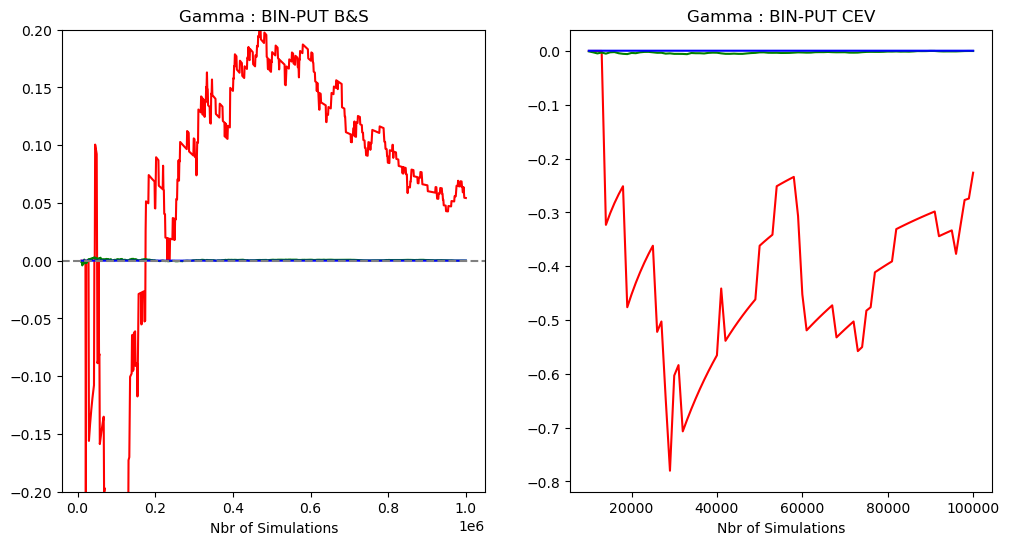

In [83]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(12, 6)

# plotting the first line
ax1.plot(gamma_bin_put['Nb sim'], gamma_bin_put['DF_anti'], color='red', label='DF', linestyle='solid')

# plotting the second line
ax1.plot(gamma_bin_put['Nb sim'], gamma_bin_put['DF_d_anti'], color='green', label='DF dec. step', linestyle='solid')

# plotting the third line
ax1.plot(gamma_bin_put['Nb sim'], gamma_bin_put['Mall_anti'], color='blue', label='Malliavin', linestyle='solid')

# plotting the horizontal line
ax1.axhline(y=-0.00005, color='grey', linestyle='dashed', label='Exact Value')

# setting y-axis limits
ax1.set_ylim((-0.2,0.2))

# adding labels to the axes
ax1.set_xlabel('Nbr of Simulations')
ax1.set_ylabel('')
ax1.set_title('Gamma : BIN-PUT B&S')

# plotting the first line
ax2.plot(gamma_bin_put_cev['Nb sim'], gamma_bin_put_cev['DF_anti'], color='red', label='DF', linestyle='solid')

# plotting the second line
ax2.plot(gamma_bin_put_cev['Nb sim'], gamma_bin_put_cev['DF_d_anti'], color='green', label='DF dec. step', linestyle='solid')

# plotting the third line
ax2.plot(gamma_bin_put_cev['Nb sim'], gamma_bin_put_cev['Mall_anti'], color='blue', label='Malliavin', linestyle='solid')

# adding labels to the axes
ax2.set_xlabel('Nbr of Simulations')
ax2.set_ylabel('')
ax2.set_title('Gamma : BIN-PUT CEV')


plt.show()

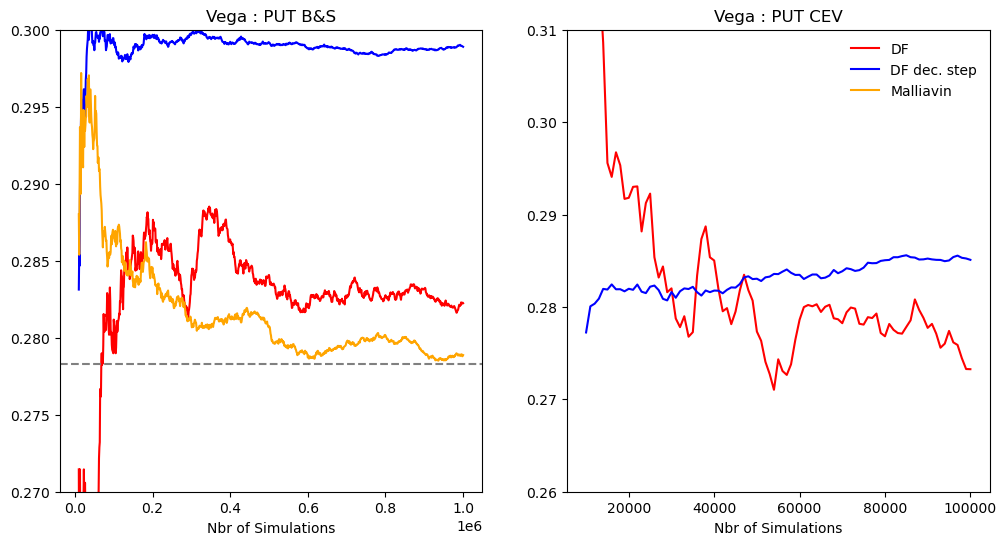

In [86]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(12, 6)

# plot settings
ax1.set_ylim(0.27,0.3)
ax1.set_xlabel("Nbr of Simulations")
ax1.set_ylabel("")
ax1.set_title("Vega : PUT B&S")

# plot lines
ax1.plot(vega_bin_put['Nb sim'], vega_bin_put['DF_anti'], color='red', label='DF')
ax1.plot(vega_bin_put['Nb sim'], vega_bin_put['DF_d_anti'], color='blue', label='DF dec. step')
ax1.plot(vega_bin_put['Nb sim'], vega_bin_put['Mall_anti'], color='orange', label='Malliavin')
ax1.axhline(y=0.27828, color='gray', linestyle='--')

ax2.set_ylim(0.26,0.31)
ax2.set_xlabel("Nbr of Simulations")
ax2.set_ylabel("")
ax2.set_title("Vega : PUT CEV")

# plot lines
ax2.plot(vega_bin_put_cev['Nb sim'], vega_bin_put_cev['DF_anti'], color='red', label='DF')
ax2.plot(vega_bin_put_cev['Nb sim'], vega_bin_put_cev['DF_d_anti'], color='blue', label='DF dec. step')
ax2.plot(vega_bin_put_cev['Nb sim'], vega_bin_put_cev['Mall_anti'], color='orange', label='Malliavin')

# add legend
plt.legend(loc='upper right', frameon=False)
plt.show()



